# Exploratory Data Analysis (EDA) of eBird Data
*Understanding Bird Observations, Species Distribution, and Trends*  

---

### Introduction

Hi! 
In this notebook, we explore **[eBird](https://ebird.org/home) data**, one of the largest biodiversity citizen-science projects established by Cornell Lab of Ornithology.We'll be focusing on a small regional dataset from Dane County, WI (2015–2025) to dive into:
- Dataset Overview
- Temporal Trends in Birding Activity  
- Birding Behavior by Birder Engagement

As a local birder myself, I’ve always been curious about questions like:
- Has there been an increase in the number of eBirders over the past 10 years?
- Do most birders go out on weekends?
- Is there a noticeable increase in birding activity during migration seasons?
- What are the most popular birding sites or those with the highest species diversity?
- Does Dane County’s favorite birding site change from year to year between 2015–2025?

By exploring these questions, we hope to better understand our local birding community and potentially offer useful insights to local Audubon groups for outreach planning and event scheduling.
Feel free to explore your own area by simply loading eBird data for your county!

Curious about what I found? Scroll to the bottom for a quick summary of the analysis!

---

### Data used in this Notebook

1. Dane County, WI eBird data between 2015 Jan - 2025 Jan. [Dowload](https://ebird.org/data/download) 
2. Climate data that include precipitation, temp between 2015 Jan - 2025 Jan. [Dowload](https://prism.oregonstate.edu/explorer/) 

## Load Data

In [ ]:
# data analysis and wrangling
import pandas as pd
import numpy as np


# visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Rectangle
from matplotlib.dates import YearLocator, DateFormatter

# stats tests
from scipy.stats import normaltest
from scipy.stats import linregress

# machine learning
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import GridSearchCV
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_absolute_error, r2_score
# from prophet import Prophet
# from statsmodels.tsa.statespace.sarimax import SARIMAX



# Set display options to show all columns and rows (but with scrollbars)
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows
pd.set_option('display.float_format', '{:,.0f}'.format)

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

/Users/silviaaaaaa/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [ ]:
ebird = pd.read_csv('.../ebd_US-WI-025_201501_202501_smp_relFeb-2025.txt', sep='\t')
prism_WI_dane_county = pd.read_csv('.../PRISM_ppt_tmin_tmean_tmax_provisional_800m_20150101_20250131_43.0674_-89.4183.csv', skiprows=10)

## Describe eBird Data

**Which features are available in the dataset?**

These feature names are described on the eBird_Basic_Dataset_Metadata_v1.15.pdf.

In [4]:
print(ebird.columns.values)

['GLOBAL UNIQUE IDENTIFIER' 'LAST EDITED DATE' 'TAXONOMIC ORDER'
 'CATEGORY' 'TAXON CONCEPT ID' 'COMMON NAME' 'SCIENTIFIC NAME'
 'SUBSPECIES COMMON NAME' 'SUBSPECIES SCIENTIFIC NAME' 'EXOTIC CODE'
 'OBSERVATION COUNT' 'BREEDING CODE' 'BREEDING CATEGORY' 'BEHAVIOR CODE'
 'AGE/SEX' 'COUNTRY' 'COUNTRY CODE' 'STATE' 'STATE CODE' 'COUNTY'
 'COUNTY CODE' 'IBA CODE' 'BCR CODE' 'USFWS CODE' 'ATLAS BLOCK' 'LOCALITY'
 'LOCALITY ID' 'LOCALITY TYPE' 'LATITUDE' 'LONGITUDE' 'OBSERVATION DATE'
 'TIME OBSERVATIONS STARTED' 'OBSERVER ID' 'SAMPLING EVENT IDENTIFIER'
 'PROTOCOL TYPE' 'PROTOCOL CODE' 'PROJECT CODE' 'DURATION MINUTES'
 'EFFORT DISTANCE KM' 'EFFORT AREA HA' 'NUMBER OBSERVERS'
 'ALL SPECIES REPORTED' 'GROUP IDENTIFIER' 'HAS MEDIA' 'APPROVED'
 'REVIEWED' 'REASON' 'TRIP COMMENTS' 'SPECIES COMMENTS' 'Unnamed: 49']


In [5]:
ebird.head()

,GLOBAL UNIQUE IDENTIFIER,LAST EDITED DATE,TAXONOMIC ORDER,CATEGORY,TAXON CONCEPT ID,COMMON NAME,SCIENTIFIC NAME,SUBSPECIES COMMON NAME,SUBSPECIES SCIENTIFIC NAME,EXOTIC CODE,OBSERVATION COUNT,BREEDING CODE,BREEDING CATEGORY,BEHAVIOR CODE,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,IBA CODE,BCR CODE,USFWS CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,TIME OBSERVATIONS STARTED,OBSERVER ID,SAMPLING EVENT IDENTIFIER,PROTOCOL TYPE,PROTOCOL CODE,PROJECT CODE,DURATION MINUTES,EFFORT DISTANCE KM,EFFORT AREA HA,NUMBER OBSERVERS,ALL SPECIES REPORTED,GROUP IDENTIFIER,HAS MEDIA,APPROVED,REVIEWED,REASON,TRIP COMMENTS,SPECIES COMMENTS,Unnamed: 49
0,URN:CornellLabOfOrnithology:EBIRD:OBS294566730,2017-07-17 13:48:19,8209,spuh,avibase-CA08045E,Accipitrine hawk sp. (former Accipiter sp.),Aerospiza/Tachyspiza/Accipiter/Astur sp.,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,US-WI_3635,23,NaN,NaN,WI - Prairie du Sac Wollersheim Winery,L3187307,P,43,-90,2015-01-31,15:00:00,obsr213338,S21647178,Stationary,P21,EBIRD,20,NaN,NaN,4,1,NaN,0,1,0,NaN,NaN,NaN,NaN
1,URN:CornellLabOfOrnithology:EBIRD:OBS293977598,2021-03-30 02:26:51.250642,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Dyreson Road Bridge,L2720718,P,43,-89,2015-01-30,10:27:00,obsr384920,S21600893,Stationary,P21,EBIRD,4,NaN,NaN,2,1,G1129663,0,1,0,NaN,"<br />Submitted from BirdLog NA for iOS, versi...",NaN,NaN
2,URN:CornellLabOfOrnithology:EBIRD:OBS294098919,2021-04-01 21:33:26.357322,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Babcock County Park,L662891,H,43,-89,2015-01-30,13:15:00,obsr151037,S21609879,Stationary,P21,EBIRD,30,NaN,NaN,4,1,G1129804,0,1,0,NaN,NaN,NaN,NaN
3,URN:CornellLabOfOrnithology:EBIRD:OBS292844052,2020-04-21 16:52:54,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Lower Mud Lake (Dane Co.),L274656,H,43,-89,2015-01-23,16:32:00,obsr438170,S21510913,Stationary,P21,EBIRD,59,NaN,NaN,2,1,NaN,0,1,0,NaN,With Jude Vickery Submitted from BirdLog NA f...,NaN,NaN
4,URN:CornellLabOfOrnithology:EBIRD:OBS294268996,2020-04-21 16:52:54,550,species,avibase-C732CB10,American Black Duck,Anas rubripes,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,United States,US,Wisconsin,US-WI,Dane,US-WI-025,NaN,23,NaN,NaN,Lower Mud Lake (Dane Co.),L274656,H,43,-89,2015-01-31,11:00:00,obsr381800,S21623656,Traveling,P22,EBIRD,40,3,NaN,1,1,NaN,0,1,0,NaN,NaN,NaN,NaN


### Initial Data Cleaning

In [6]:
# drop irrelevant column - Unnamed: 49 
ebird = ebird.drop(columns=['Unnamed: 49'])

**Check Column Types and Update Accordingly**

In [7]:
prism_WI_dane_county['Date'] = pd.to_datetime(prism_WI_dane_county['Date'])

In [8]:
# Display column data types
print("Current Data Types:")
print(ebird.dtypes)

# Get numeric vs. non-numeric breakdown
numeric_cols = ebird.select_dtypes(include=['number']).columns
non_numeric_cols = ebird.select_dtypes(exclude=['number']).columns

print(f"\nNumeric Columns: {list(numeric_cols)}")
print(f"Non-Numeric Columns: {list(non_numeric_cols)}")

Current Data Types:
GLOBAL UNIQUE IDENTIFIER       object
LAST EDITED DATE               object
TAXONOMIC ORDER                 int64
CATEGORY                       object
TAXON CONCEPT ID               object
COMMON NAME                    object
SCIENTIFIC NAME                object
SUBSPECIES COMMON NAME         object
SUBSPECIES SCIENTIFIC NAME     object
EXOTIC CODE                    object
OBSERVATION COUNT              object
BREEDING CODE                  object
BREEDING CATEGORY              object
BEHAVIOR CODE                  object
AGE/SEX                        object
COUNTRY                        object
COUNTRY CODE                   object
STATE                          object
STATE CODE                     object
COUNTY                         object
COUNTY CODE                    object
IBA CODE                       object
BCR CODE                        int64
USFWS CODE                     object
ATLAS BLOCK                    object
LOCALITY                      

In [9]:
# Define type conversion rules
type_updates = {
    # Date/Time
    'OBSERVATION DATE': 'datetime64[ns]',
    'LAST EDITED DATE': 'datetime64[ns]',
    'TIME OBSERVATIONS STARTED': 'datetime64[ns]'
    
    # Numeric (handle non-numeric entries)
    # 'OBSERVATION COUNT': 'int' #Skip conversion as it has non-numeric entries
}

# Convert columns with error handling
for col, dtype in type_updates.items():
    try:
        if dtype == 'datetime64[ns]':
            ebird[col] = pd.to_datetime(ebird[col], errors='coerce')
        elif dtype == 'float64':
            ebird[col] = pd.to_numeric(ebird[col], errors='coerce')
        else:
            ebird[col] = ebird[col].astype(dtype)
    except Exception as e:
        print(f"Failed to convert {col}: {str(e)}")

### Enrich Dataset

**Add Weather Info**

In [10]:
# join ebird with prism_WI_dane_county
ebird = pd.merge(ebird, prism_WI_dane_county, left_on='OBSERVATION DATE', right_on='Date', how='left')
ebird = ebird.drop(columns=['Date'])

**Extract Temporal Features**

In [11]:
ebird['YEAR'] = pd.to_datetime(ebird['OBSERVATION DATE']).dt.year
ebird['MONTH'] = pd.to_datetime(ebird['OBSERVATION DATE']).dt.month
ebird['HOUR'] = pd.to_datetime(ebird['TIME OBSERVATIONS STARTED']).dt.hour
ebird['DAY_OF_WEEK'] = pd.to_datetime(ebird['OBSERVATION DATE']).dt.dayofweek
ebird['DAY_OF_YEAR'] = pd.to_datetime(ebird['OBSERVATION DATE']).dt.dayofyear 

**Global Big Days**

In [12]:
# Global Big Day dates (second Saturday in May each year)
big_day_dates = {
    2015: '2015-05-09',
    2016: '2016-05-14',
    2017: '2017-05-13',
    2018: '2018-05-12',
    2019: '2019-05-11',
    2020: '2020-05-09',
    2021: '2021-05-08',
    2022: '2022-05-14',
    2023: '2023-05-13',
    2024: '2024-05-11',
    2025: '2025-05-10'
}

# Convert observation dates to datetime if not already
ebird['OBSERVATION DATE'] = pd.to_datetime(ebird['OBSERVATION DATE'])

# Create new column marking Global Big Day
ebird['IS_GLOBAL_BIG_DAY'] = ebird['OBSERVATION DATE'].isin(pd.to_datetime(list(big_day_dates.values())))
ebird['IS_GLOBAL_BIG_DAY'] = ebird['IS_GLOBAL_BIG_DAY'].astype(int)

**Birder Stats**

In [13]:
# Calculate birder stats
birder_stats = ebird.groupby('OBSERVER ID').agg(
    total_checklists=('SAMPLING EVENT IDENTIFIER', 'nunique'),
    total_species=('COMMON NAME', 'nunique')
).reset_index()

# Define tiers (adjust percentiles as needed)
top_threshold = birder_stats['total_checklists'].quantile(0.9)
bottom_threshold = birder_stats['total_checklists'].quantile(0.1)

birder_stats['birder_tier'] = pd.cut(
    birder_stats['total_checklists'],
    bins=[-1, bottom_threshold, top_threshold, float('inf')],
    labels=['bottom', 'regular', 'top']
)

# Merge back to original data
ebird = ebird.merge(
    birder_stats[['OBSERVER ID', 'birder_tier']],
    on='OBSERVER ID',
    how='left'
)

### Create Table for Different Granularity and Use Case

In [14]:
# get subset of numeric values in OBSERVATION COUNT and convert to numeric
ebird_numeric_count_only = ebird[ebird['OBSERVATION COUNT'] != 'X'].dropna(subset=['OBSERVATION COUNT'])
ebird_numeric_count_only['OBSERVATION COUNT'] = pd.to_numeric(ebird_numeric_count_only['OBSERVATION COUNT'])

In [15]:
# Group by checklist ID and check for multiple values
inconsistent_checklists = (
    ebird.groupby('SAMPLING EVENT IDENTIFIER')
    .agg({
        'DURATION MINUTES': 'nunique',
        'EFFORT DISTANCE KM': 'nunique',
        'EFFORT AREA HA': 'nunique',
        'LOCALITY': 'nunique'
    })
    .rename(columns={
        'DURATION MINUTES': 'duration_variations',
        'EFFORT DISTANCE KM': 'distance_variations',
        'EFFORT AREA HA': 'area_variations',
        'LOCALITY': 'locality_variations'
    })
    .query('duration_variations > 1 or distance_variations > 1 or area_variations > 1 or locality_variations > 1')
    .reset_index()
)

# Get full details of problematic checklists
problem_details = ebird[
    ebird['SAMPLING EVENT IDENTIFIER'].isin(inconsistent_checklists['SAMPLING EVENT IDENTIFIER'])
].sort_values('SAMPLING EVENT IDENTIFIER')

# Print summary
print(f"Found {len(inconsistent_checklists)} checklists with inconsistent metadata:")

Found 0 checklists with inconsistent metadata:


**All Checklists Share the Same Duration, Distance, Area, Locality**

In [16]:
ebird_checklists = (
    ebird_numeric_count_only.groupby('SAMPLING EVENT IDENTIFIER')
    .agg({
        'COMMON NAME': ['nunique'],           # Unique species
        'OBSERVATION COUNT': 'sum',           # Total individuals observed
        'LOCALITY': 'first',                  # Location info
        'OBSERVATION DATE': 'first',
        'TIME OBSERVATIONS STARTED': 'first',
        'DURATION MINUTES': 'first',
        'EFFORT DISTANCE KM': 'first',
        'EFFORT AREA HA': 'first',
        'HAS MEDIA': 'any'                    # Whether checklist has media
    })
    .reset_index()
)

# Flatten multi-level column names
ebird_checklists.columns = [
    'SAMPLING EVENT IDENTIFIER', 'UNIQUE SPECIES OBSERVED',
    'OBSERVATION COUNT', 'LOCALITY', 'OBSERVATION DATE',
    'TIME OBSERVATIONS STARTED', 'DURATION MINUTES', 'EFFORT DISTANCE KM',
    'EFFORT AREA HA', 'HAS MEDIA'
]

# Convert date/time columns
ebird_checklists['OBSERVATION DATE'] = pd.to_datetime(ebird_checklists['OBSERVATION DATE'])
ebird_checklists['TIME OBSERVATIONS STARTED'] = pd.to_datetime(ebird_checklists['TIME OBSERVATIONS STARTED']).dt.time

# Show the first 5 checklists
ebird_checklists.head()

,SAMPLING EVENT IDENTIFIER,UNIQUE SPECIES OBSERVED,OBSERVATION COUNT,LOCALITY,OBSERVATION DATE,TIME OBSERVATIONS STARTED,DURATION MINUTES,EFFORT DISTANCE KM,EFFORT AREA HA,HAS MEDIA
0,S100007427,3,5,Private Residence (Lakewood Gardens Lane),2022-01-01,08:00:00,NaN,NaN,NaN,False
1,S100007831,1,1,Home,2022-01-03,07:39:00,1,NaN,NaN,False
2,S100008288,2,3,"CTH-PD, Verona",2022-01-02,12:27:00,NaN,NaN,NaN,False
3,S100008289,2,3,"CTH-PD, Verona",2022-01-02,12:27:00,NaN,NaN,NaN,False
4,S100008533,6,15,"1317 North Wingra Drive, Madison, Wisconsin, U...",2022-01-03,07:28:00,24,NaN,NaN,False


### Describe Data

**What data range is included in this analysis (e.g., time period, geographic scope)?**

In [32]:
# Temporal Range
date_min = ebird['OBSERVATION DATE'].min().strftime('%Y-%m-%d')
date_max = ebird['OBSERVATION DATE'].max().strftime('%Y-%m-%d')

# Geographic Scope (assuming latitude/longitude columns exist)
geo_scope = ebird[['COUNTRY', 'STATE', 'COUNTY']].drop_duplicates().values[0]

# Checklist Counts
total_checklists = len(ebird)
unique_days = ebird['OBSERVATION DATE'].nunique()

print(f"""
DATA SCOPE SUMMARY:
---------------------------------
Time Period:     {date_min} to {date_max}
                  ({unique_days} days with observations)
                  
Geographic: {geo_scope[0]}, {geo_scope[1]}, {geo_scope[2]}

Total Checklists: {total_checklists:,}  
Unique Species:   {ebird['COMMON NAME'].nunique():,}
---------------------------------
""")


DATA SCOPE SUMMARY:
---------------------------------
Time Period:     2015-01-01 to 2025-01-31
                  (3684 days with observations)
                  
Geographic: United States, Wisconsin, Dane

Total Checklists: 4,298,659  
Unique Species:   465
---------------------------------



**Check Missing Values**

In [18]:
# columns with missing value
missing_pct = ebird.isnull().mean() * 100
missing_pct[missing_pct > 0]

LAST EDITED DATE              92
SUBSPECIES COMMON NAME        99
SUBSPECIES SCIENTIFIC NAME    99
EXOTIC CODE                   93
BREEDING CODE                 97
BREEDING CATEGORY             97
BEHAVIOR CODE                 97
AGE/SEX                       99
IBA CODE                      87
USFWS CODE                    98
ATLAS BLOCK                   96
TIME OBSERVATIONS STARTED      1
DURATION MINUTES               5
EFFORT DISTANCE KM            26
EFFORT AREA HA               100
NUMBER OBSERVERS               1
GROUP IDENTIFIER              79
REASON                       100
TRIP COMMENTS                 86
SPECIES COMMENTS              96
HOUR                           1
dtype: float64

**What is the distribution of numerical feature values across the samples?**

Checklist Completeness Summary:
- 16.6% lack duration data
- 47.8% lack distance data
- 99.9% lack area data
- 13.2% of checklists have media

Birding Effort Summary with Available Data:
- Median outing duration: 37.0 minutes
- Long outings (top 5%): over 152.0 minutes
- Median distance covered: 1.6 km
- Extensive surveys (top 5%): beyond 5.3 km
- Due to high % of missing value in area data, analyzing it is not as meaningful
- 27.7% of checklists starts between 5:00 AM - 8:00 AM, when birds are most active.
- 95% of checklists have duration <= 3.2 hour and <= 6 km

In [19]:
ebird_checklists.head()

,SAMPLING EVENT IDENTIFIER,UNIQUE SPECIES OBSERVED,OBSERVATION COUNT,LOCALITY,OBSERVATION DATE,TIME OBSERVATIONS STARTED,DURATION MINUTES,EFFORT DISTANCE KM,EFFORT AREA HA,HAS MEDIA
0,S100007427,3,5,Private Residence (Lakewood Gardens Lane),2022-01-01,08:00:00,NaN,NaN,NaN,False
1,S100007831,1,1,Home,2022-01-03,07:39:00,1,NaN,NaN,False
2,S100008288,2,3,"CTH-PD, Verona",2022-01-02,12:27:00,NaN,NaN,NaN,False
3,S100008289,2,3,"CTH-PD, Verona",2022-01-02,12:27:00,NaN,NaN,NaN,False
4,S100008533,6,15,"1317 North Wingra Drive, Madison, Wisconsin, U...",2022-01-03,07:28:00,24,NaN,NaN,False


In [20]:
# Calculate missing value percentages
missing_stats = ebird_checklists[['DURATION MINUTES', 'EFFORT DISTANCE KM', 'EFFORT AREA HA']].isnull().mean() * 100

# Generate natural language summary
summary = (
    f"Checklist Completeness Summary:\n"
    f"- {missing_stats['DURATION MINUTES']:.1f}% lack duration data\n"
    f"- {missing_stats['EFFORT DISTANCE KM']:.1f}% lack distance data\n"
    f"- {missing_stats['EFFORT AREA HA']:.1f}% lack area data\n"
    f"- {ebird_checklists['HAS MEDIA'].sum() / len(ebird_checklists) * 100:.1f}% of checklists have media\n"
)

print(summary)

Checklist Completeness Summary:
- 16.6% lack duration data
- 47.8% lack distance data
- 99.9% lack area data
- 13.2% of checklists have media



In [21]:
# Calculate statistics
duration_med = ebird_checklists['DURATION MINUTES'].median()
duration_95 = ebird_checklists['DURATION MINUTES'].quantile(0.95)
distance_med = ebird_checklists['EFFORT DISTANCE KM'].median()
distance_95 = ebird_checklists['EFFORT DISTANCE KM'].quantile(0.95)

# Print formatted summary
print(
    "Birding Effort Summary:\n"
    f"- Median outing duration: {duration_med:.1f} minutes\n"
    f"- Long outings (top 5%): over {duration_95:.1f} minutes\n"
    f"- Median distance covered: {distance_med:.1f} km\n"
    f"- Extensive surveys (top 5%): beyond {distance_95:.1f} km\n"
)

Birding Effort Summary:
- Median outing duration: 37.0 minutes
- Long outings (top 5%): over 152.0 minutes
- Median distance covered: 1.6 km
- Extensive surveys (top 5%): beyond 5.3 km



### Outliers

Certain numeric columns—such as DURATION MINUTES, EFFORT DISTANCE KM, and EFFORT AREA HA—are prone to outliers or inaccurately logged data. For example, a birder may forget to end a checklist, resulting in unusually long durations, distances, or areas. To address this, we use a combined approach of quantile analysis and domain knowledge to define outlier thresholds.

Outlier Observation Summary
1. Extreme Checklists Identified:

Prolonged Duration: ~0.6% of checklists exceed 12 hours.

2. Analytical Implications:

Avoid mean-based metrics for duration/distance, as outliers skew results.

Recommended Approach:

Use median and quantiles (e.g., 75th/95th percentiles).

Filter extreme values (>12hr or >8.7km) for robust statistics.

In [22]:
ebird[['DURATION MINUTES', 'EFFORT DISTANCE KM']].describe(percentiles=[.01, .25, .5, .75, .95, .99])

,DURATION MINUTES,EFFORT DISTANCE KM
count,"4,078,618","3,180,841"
mean,77,3
std,67,3
min,1,0
1%,4,0
25%,30,1
50%,60,2
75%,105,3
95%,191,6
99%,282,9


In [23]:
# Calculate 99th percentiles
thresholds = {
    'duration': 720,  # 12 hours
    'distance': ebird['EFFORT DISTANCE KM'].quantile(0.99)
}

print(thresholds)
# Identify extreme checklists
extreme_flags = (
    ebird.groupby('SAMPLING EVENT IDENTIFIER')
    .agg(
        DURATION_EXTREME=('DURATION MINUTES', lambda x: x.max() > thresholds['duration']),
        DISTANCE_EXTREME=('EFFORT DISTANCE KM', lambda x: x.max() > thresholds['distance'])
    )
)

# Calculate percentages
total_checklists = extreme_flags.shape[0]
results = {
    'Any extreme': extreme_flags.any(axis=1).mean() * 100,
    'Duration only': extreme_flags['DURATION_EXTREME'].mean() * 100,
    'Distance only': extreme_flags['DISTANCE_EXTREME'].mean() * 100
}

# Print formatted results
print(f"{'Metric':<15} {'% of Checklists':>15}")
print("-" * 30)
for k, v in results.items():
    print(f"{k:<15} {v:>15.1f}%")

{'duration': 720, 'distance': np.float64(8.673)}
Metric          % of Checklists
------------------------------
Any extreme                 0.6%
Duration only               0.0%
Distance only               0.6%


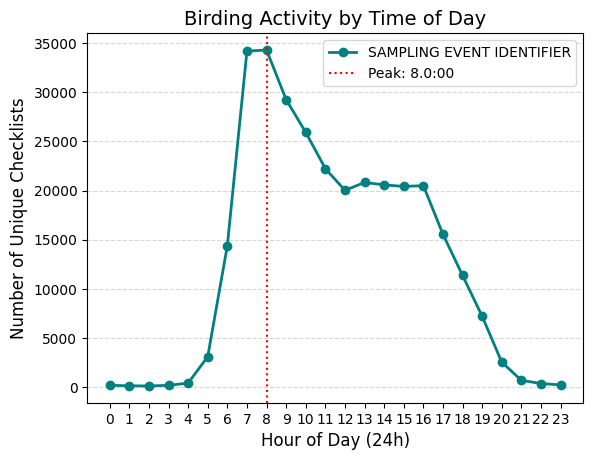

In [24]:
# Count unique checklists per hour
hourly_counts = ebird.groupby('HOUR')['SAMPLING EVENT IDENTIFIER'].nunique()

# Plot line graph
plt.figure()
hourly_counts.plot(
    kind='line',
    marker='o',      # Add dots for each data point
    linestyle='-',    # Solid line
    linewidth=2,
    color='teal'
)

# Customize plot
plt.title('Birding Activity by Time of Day', fontsize=14)
plt.xlabel('Hour of Day (24h)', fontsize=12)
plt.ylabel('Number of Unique Checklists', fontsize=12)
plt.xticks(range(24))  # Show all hours
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Highlight peak hours
peak_hour = hourly_counts.idxmax()
plt.axvline(x=peak_hour, color='red', linestyle=':', label=f'Peak: {peak_hour}:00')
plt.legend()

plt.show()

In [25]:
# Calculate total unique checklists
total_checklists = ebird['SAMPLING EVENT IDENTIFIER'].nunique()

# Count checklists between 5-8 AM
morning_checklists = ebird[ebird['HOUR'].between(5, 8)]['SAMPLING EVENT IDENTIFIER'].nunique()

# Calculate percentage
morning_percentage = (morning_checklists / total_checklists) * 100

print(f"{morning_percentage:.1f}% of checklists starts between 5:00 AM - 8:00 AM, when birds are most active.")

27.7% of checklists starts between 5:00 AM - 8:00 AM, when birds are most active.


**What is the distribution of categorical features?**

- 98% submitted category are species
- Top 3 most observed birds: Canada Goose, American Coot, Mallard
- Top 3 most diverse sites: Nine Springs Natural Area (318 species), UW Lakeshore Nature Preserve (general) (312 species), UW Madison Arboretum (general) (295 species). Combined they make up 80% of all 465 observed species.
- Top 3 birding hotspots (using unique count of submitted checklists): UW Madison Arboretum (general), Nine Springs Natural Area, Owen Conservation Park. These locations account for 7.4% of all 309857 checklists submitted.
- 51% of checklists are Traveling, 30% are Stationary

In [26]:
ebird['CATEGORY'].value_counts(normalize=True) * 100

CATEGORY
species      98
spuh          1
issf          1
domestic      0
slash         0
form          0
hybrid        0
intergrade    0
Name: proportion, dtype: float64

Top 3 most observed birds: Canada Goose, American Coot, Mallard


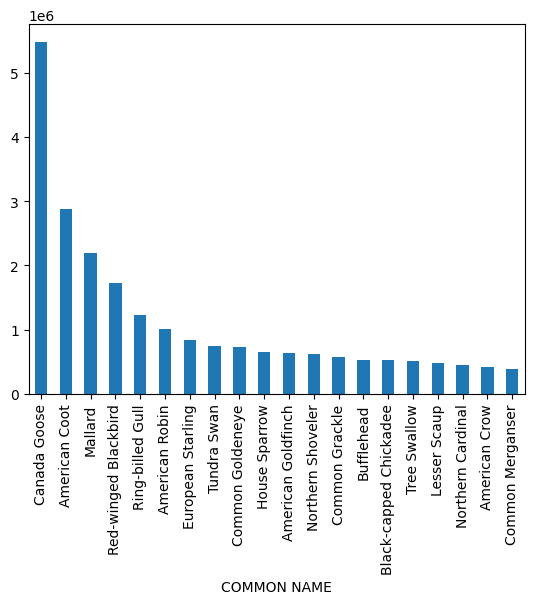

In [27]:
# top species count
top_birds = (
    ebird_numeric_count_only.groupby('COMMON NAME')['OBSERVATION COUNT']
    .sum()
    .nlargest(3)
    .index.tolist()
)

print(f"Top 3 most observed birds: {', '.join(top_birds)}")

(ebird_numeric_count_only.groupby('COMMON NAME')['OBSERVATION COUNT'].sum().nlargest(20).plot(kind='bar'))
plt.show()



In [28]:
# Get unique species at each top site
site_diversity = ebird.groupby('LOCALITY')['COMMON NAME'].nunique().sort_values(ascending=False)
top_sites = site_diversity.head(3)
top_sites_list = site_diversity.head(3).index.tolist()
total_species = ebird['COMMON NAME'].nunique()
unique_species_in_top_sites = ebird[ebird['LOCALITY'].isin(top_sites_list)]['COMMON NAME'].nunique()

# Calculate percentage
pct_combined = round(unique_species_in_top_sites / total_species * 100)  

# Generate summary
summary = (
    f"Top 3 most diverse sites: " +
    ', '.join([f"{site} ({count} species)" for site, count in top_sites.head(3).items()]) +
    f".\nCombined they make up {pct_combined}% of all {total_species} observed species."
)

print(summary)

Top 3 most diverse sites: Nine Springs Natural Area (318 species), UW Lakeshore Nature Preserve (general) (312 species), UW Madison Arboretum (general) (295 species).
Combined they make up 80% of all 465 observed species.


Top 3 birding hotspots (using unique count of submitted checklists): UW Madison Arboretum (general), Nine Springs Natural Area, Owen Conservation Park.
These locations account for 7.4% of all 309857 checklists submitted.


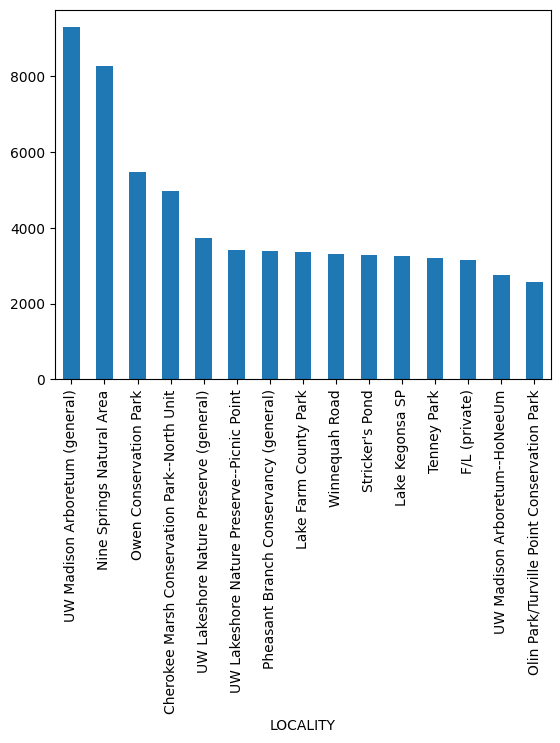

In [29]:
# Calculate unique checklists per site
hotspot_popularity = ebird.groupby('LOCALITY')['SAMPLING EVENT IDENTIFIER'].nunique().sort_values(ascending=False)
top3_hotspots = hotspot_popularity.head(3)
total_checklists = ebird['SAMPLING EVENT IDENTIFIER'].nunique()
hotspot_pct = round(top3_hotspots.sum() / total_checklists * 100, 1)

# Generate summary
hotspot_summary = (
    f"Top 3 birding hotspots (using unique count of submitted checklists): " +
    ', '.join([f"{site}" for site in top3_hotspots.index]) +
    f".\nThese locations account for {hotspot_pct}% of all {total_checklists} checklists submitted."
)

print(hotspot_summary)

(ebird.groupby('LOCALITY')['SAMPLING EVENT IDENTIFIER'].nunique().nlargest(15).plot(kind='bar'))
plt.show()

In [30]:
# Count UNIQUE checklists by protocol type
protocol_counts = ebird.groupby('PROTOCOL TYPE')['SAMPLING EVENT IDENTIFIER'].nunique()
total_checklists = protocol_counts.sum()

# Calculate percentages (whole numbers)
traveling_pct = int(round(protocol_counts.get('Traveling', 0) / total_checklists * 100))
stationary_pct = int(round(protocol_counts.get('Stationary', 0) / total_checklists * 100))

# Generate summary
print(f"{traveling_pct}% of checklists are Traveling, {stationary_pct}% are Stationary")

51% of checklists are Traveling, 30% are Stationary


## Understand Trends

- Number of active eBirders almost doubled starting from 2020, which is also when I(notebook auther) started birding, such a great activity to get out in the nature when you are stuck at home all day duing Covid~

- As expected, birding activity doubles on weekends, with 36.1% of checklists submitted on weekends. We observe a clear seasonal pattern in checklist submissions, with noticeable peaks during the spring and fall migration periods.

- Birding activity begins to increase in early March, reaches a sharp peak in early May, and then quickly declines before June. A smaller spike also appears in December, aligning with the annual Christmas Bird Count.

- In contrast to the intense activity during spring migration, the fall migration season is noticeably flatter and more subdued in terms of checklist volume. This could be due to lower species diversity in the fall, which peaks around 220 species, compared to the spring peak of approximately 290 species.

**Has there been an incease in number of eBirders in the past 10 year?**

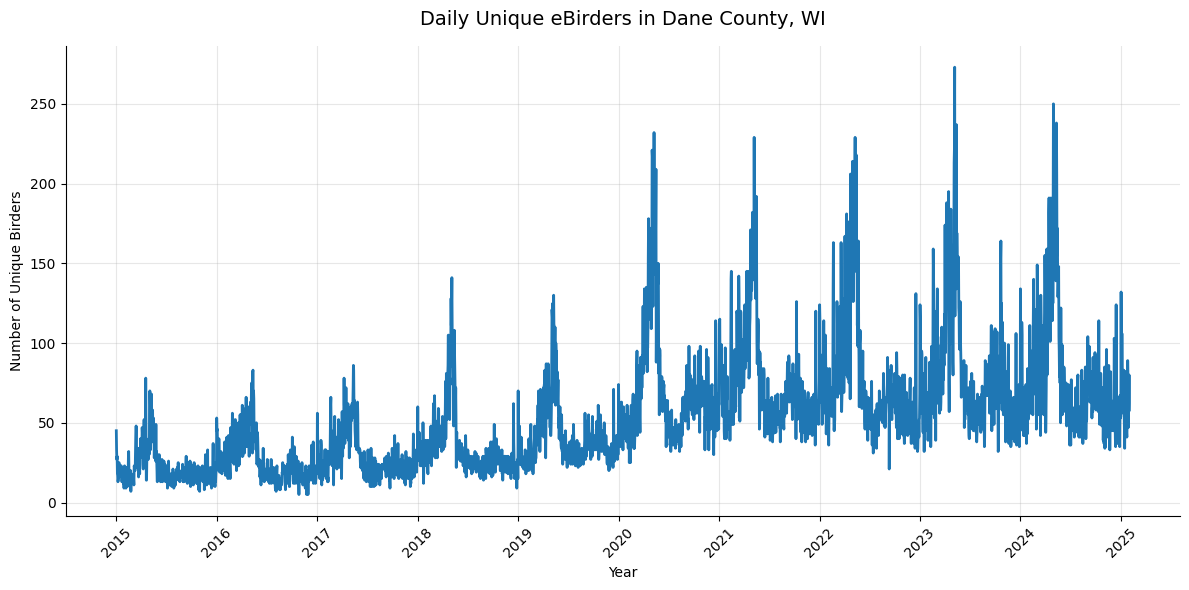

In [33]:
# Prepare data - count unique birders per day
daily_birders = (
    ebird.groupby('OBSERVATION DATE')['OBSERVER ID']
    .nunique()
    .reset_index()
    .rename(columns={'OBSERVER ID': 'unique_birders'})
)

# Create the plot
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=daily_birders,
    x='OBSERVATION DATE',
    y='unique_birders',
    color='#1f77b4',  # Matplotlib's default blue
    linewidth=2
)

# Format x-axis to show only years
ax.xaxis.set_major_locator(YearLocator())
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.xticks(rotation=45)

# Add labels and title
plt.title('Daily Unique eBirders in Dane County, WI', pad=15, fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Unique Birders')
plt.grid(alpha=0.3)

# Remove spines for cleaner look
sns.despine()

plt.tight_layout()
plt.show()

**Do most birders bird on the weekend?**

36.1% of checklists are submitted on weekends


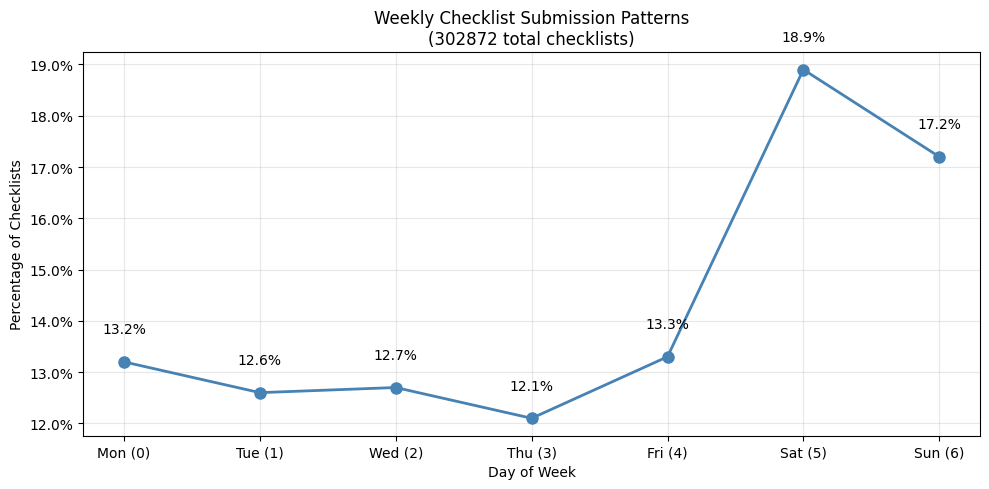

In [34]:
# Extract day of week (0=Monday to 6=Sunday)
ebird_checklists['day_of_week'] = ebird_checklists['OBSERVATION DATE'].dt.dayofweek

# Calculate daily counts and percentages
daily_counts = ebird_checklists['day_of_week'].value_counts().sort_index()
daily_pct = (daily_counts / daily_counts.sum() * 100).round(1)

# Create line plot
plt.figure(figsize=(10, 5))
ax = daily_pct.plot(
    kind='line',
    marker='o',
    color='steelblue',
    linewidth=2,
    markersize=8
)

# Formatting
ax.set_xticks(range(7))
ax.set_xticklabels(['Mon (0)', 'Tue (1)', 'Wed (2)', 'Thu (3)', 
                    'Fri (4)', 'Sat (5)', 'Sun (6)'])
ax.yaxis.set_major_formatter(ticker.PercentFormatter())
ax.set_ylabel('Percentage of Checklists')
ax.set_xlabel('Day of Week')
ax.set_title('Weekly Checklist Submission Patterns\n({} total checklists)'.format(len(ebird_checklists)))
plt.grid(alpha=0.3)

# Annotate data points
for x, y in zip(daily_pct.index, daily_pct.values):
    ax.text(x, y+0.5, f'{y}%', ha='center', va='bottom')

# Print summary
print(
    f"{(daily_pct.loc[[5, 6]].sum()).round(1)}% of checklists are submitted on weekends"
)

plt.tight_layout()
plt.show()

**Do we observe inrease in birding activities during migration seasons?**

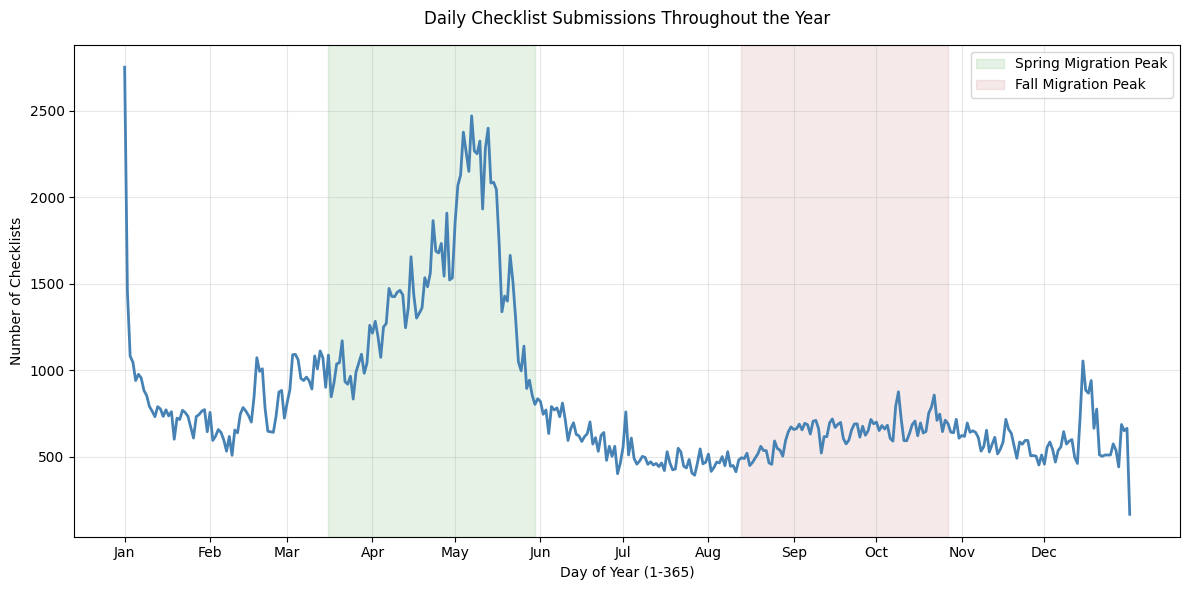

In [35]:
# Extract day of year and count checklists
daily_checklists_counts = (
    ebird_checklists['OBSERVATION DATE'].dt.dayofyear
    .value_counts()
    .sort_index()
    .reset_index()
)
daily_checklists_counts.columns = ['day_of_year', 'checklist_count']

# Dane County migration seasons (adjust as needed)
spring_migration = (75, 150)   # March 15 - May 30 (approx. days 75-150)
fall_migration = (225, 300)    # August 15 - October 30 (approx. days 225-300)


# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=daily_checklists_counts,
    x='day_of_year',
    y='checklist_count',
    color='steelblue',
    linewidth=2
)

# Add labels and titles
plt.title('Daily Checklist Submissions Throughout the Year', pad=15)
plt.xlabel('Day of Year (1-365)')
plt.ylabel('Number of Checklists')
plt.grid(alpha=0.3)

# Highlight key periods
plt.axvspan(spring_migration[0], spring_migration[1], color='green', alpha=0.1, label='Spring Migration Peak')
plt.axvspan(fall_migration[0], fall_migration[1], color='brown', alpha=0.1, label='Fall Migration Peak')
plt.legend()

# Improve x-axis labels
month_positions = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(month_positions, month_labels)

plt.tight_layout()
plt.show()

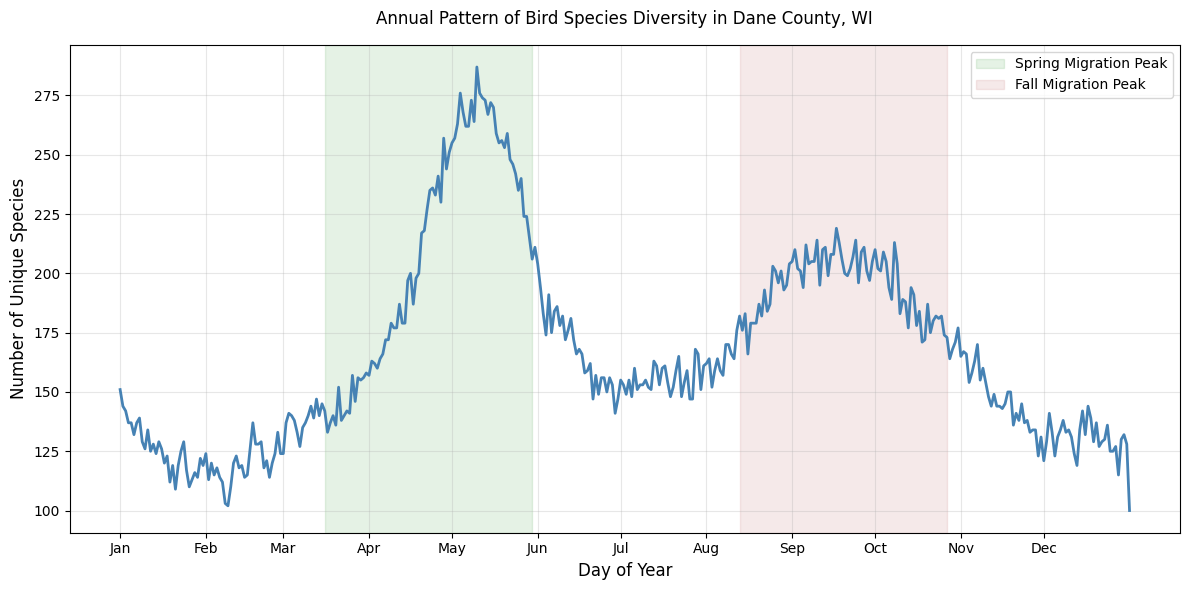

In [36]:
# Extract day of year and count checklists


daily_unique_species_counts = ebird.groupby('DAY_OF_YEAR')['COMMON NAME'].nunique().reset_index()

daily_unique_species_counts.columns = ['day_of_year', 'unique_species_count']

# Dane County migration seasons (adjust as needed)
spring_migration = (75, 150)   # March 15 - May 30 (approx. days 75-150)
fall_migration = (225, 300)    # August 15 - October 30 (approx. days 225-300)


# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=daily_unique_species_counts,
    x='day_of_year',
    y='unique_species_count',
    color='steelblue',
    linewidth=2
)

# Add labels and titles
plt.title('Annual Pattern of Bird Species Diversity in Dane County, WI', pad=15)
plt.xlabel('Day of Year', fontsize=12)
plt.ylabel('Number of Unique Species', fontsize=12)
plt.grid(alpha=0.3)

# Highlight key periods
plt.axvspan(spring_migration[0], spring_migration[1], color='green', alpha=0.1, label='Spring Migration Peak')
plt.axvspan(fall_migration[0], fall_migration[1], color='brown', alpha=0.1, label='Fall Migration Peak')
plt.legend()

# Improve x-axis labels
month_positions = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(month_positions, month_labels)

plt.tight_layout()
plt.show()

**Does birder in Dane County's favorite site changes every year between 2015-2025?**

** favoriate site defined as highest checklist submitted

In [37]:
(ebird.groupby(['YEAR', 'LOCALITY'])['SAMPLING EVENT IDENTIFIER']
.nunique()
.groupby('YEAR', group_keys=False)
.nlargest(3)
.reset_index(name='CHECKLIST COUNT'))


,YEAR,LOCALITY,CHECKLIST COUNT
0,2015,Pheasant Branch Conservancy (general),578
1,2015,Nine Springs Natural Area,536
2,2015,UW Madison Arboretum (general),482
3,2016,Nine Springs Natural Area,529
4,2016,Pheasant Branch Conservancy (general),516
5,2016,UW Madison Arboretum (general),453
6,2017,UW Madison Arboretum (general),714
7,2017,Pheasant Branch Conservancy (general),486
8,2017,F/L (private),442
9,2018,UW Madison Arboretum (general),853


**Has there been shifts in birding habits across years?**

* Time of day: consistent pattern, but observed spike in checklist submitted in 2020, checklist submitted almost doubled staring from 2020 when comparing to 2019.
* Day of Week: consistent

<Figure size 1200x600 with 0 Axes>

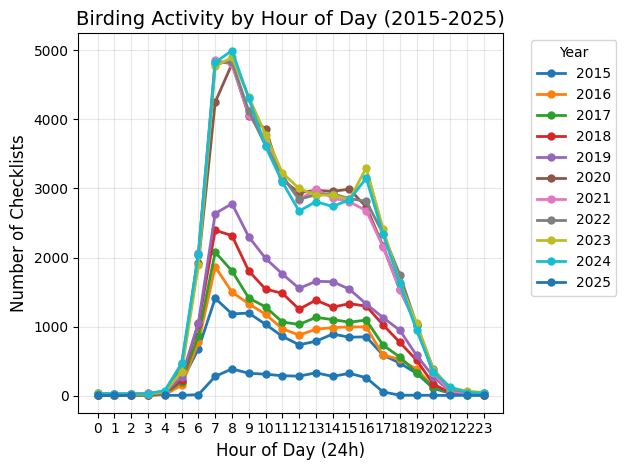

In [38]:
plt.figure(figsize=(12, 6))

# Group by year and hour, then count checklists
hourly_by_year = (
    ebird.groupby(['YEAR', 'HOUR'])['SAMPLING EVENT IDENTIFIER']
    .nunique()
    .unstack('YEAR')
)

# Plot each year's line
hourly_by_year.plot(kind='line', marker='o', linewidth=2, markersize=5)

# Customize plot
plt.title('Birding Activity by Hour of Day (2015-2025)', fontsize=14)
plt.xlabel('Hour of Day (24h)', fontsize=12)
plt.ylabel('Number of Checklists', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

# Move legend outside
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Birder Stats Analysis

If we categorize eBirders based on the number of checklists submitted into top 10%, regular, and bottom 10%, we can observe some distinct patterns in their birding behavior:
- Top 10% birders contributed 89.6% of all checklists.
- Given that top eBirders contribute nearly 90% of all checklists, their birding behavior is largely representative of overall trends observed in the data. This heavy contribution skews the aggregate patterns—such as peak birding times and trip characteristics—toward the habits of this highly active group.
- Top birders are more likely to start birding early in the morning: 38% of top birders begin before 9 AM, compared to only 29% of bottom birders.
- They also tend to have shorter trips—both in terms of duration and distance.
- Despite shorter trips, top birders observe significantly more species:
    - Top 10%: Average of 12.78 species per checklist
    - Regular: Average of 1.01 species
    - Bottom 10%: Only 0.07 species on average
- This suggests that top birders are not only more experienced and efficient but also likely more deliberate in their birding efforts.

In [39]:
# Calculate checklist counts by tier
tier_summary = (
    ebird.groupby('birder_tier')
    .agg(
        total_checklists=('SAMPLING EVENT IDENTIFIER', 'nunique'),
        unique_birders=('OBSERVER ID', 'nunique'),
        avg_checklists_per_birder=('SAMPLING EVENT IDENTIFIER', lambda x: x.nunique() / x.nunique())
    )
    .reset_index()
)

# Calculate percentages
total = tier_summary['total_checklists'].sum()
tier_summary['pct_of_total'] = (tier_summary['total_checklists'] / total * 100).round(1)

top_checklists = ebird[ebird['birder_tier'] == 'top']['SAMPLING EVENT IDENTIFIER'].nunique()
total_checklists = ebird['SAMPLING EVENT IDENTIFIER'].nunique()

# Print formatted summary
print(
    "Checklist Submission Summary by Birder Tier:\n"
    "-------------------------------------------"
)
for _, row in tier_summary.iterrows():
    print(
        f"{row['birder_tier'].title()} Birders:\n"
        f"- Submitted {row['total_checklists']:,} checklists ({row['pct_of_total']}% of total)\n"
        f"- {row['unique_birders']} unique birders\n"
    )

# Print overall stats
print(f"Top 10% birders contributed {100 * top_checklists / total_checklists:.1f}% of all checklists.")

Checklist Submission Summary by Birder Tier:
-------------------------------------------
Bottom Birders:
- Submitted 2,599 checklists (0.8% of total)
- 2599 unique birders

Regular Birders:
- Submitted 29,613 checklists (9.6% of total)
- 3851 unique birders

Top Birders:
- Submitted 277,645 checklists (89.6% of total)
- 716 unique birders

Top 10% birders contributed 89.6% of all checklists.


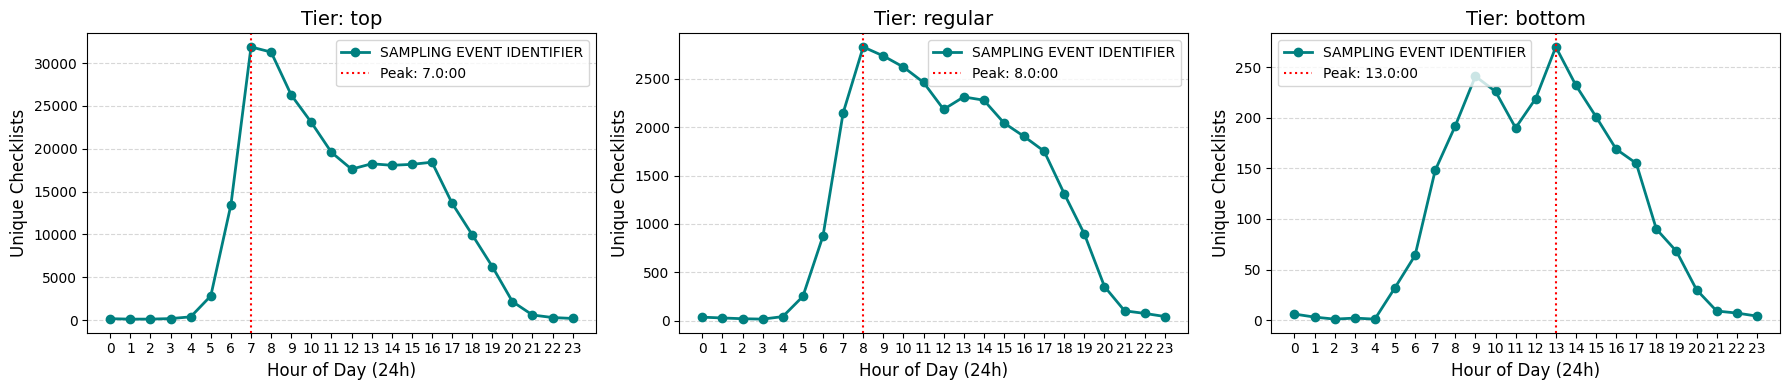

In [40]:
# Get all unique tiers
tiers = ebird['birder_tier'].unique()
n_tiers = len(tiers)

# Set up the figure with subplots side by side
fig, axes = plt.subplots(1, n_tiers, figsize=(6 * n_tiers, 4), sharey=False)

# Ensure axes is always iterable
if n_tiers == 1:
    axes = [axes]

# Loop through each tier and corresponding subplot
for ax, tier in zip(axes, tiers):
    group = ebird[ebird['birder_tier'] == tier]
    hourly_counts = group.groupby('HOUR')['SAMPLING EVENT IDENTIFIER'].nunique()

    # Plot
    hourly_counts.plot(
        ax=ax,
        kind='line',
        marker='o',
        linestyle='-',
        linewidth=2,
        color='teal'
    )

    ax.set_title(f'Tier: {tier}', fontsize=14)
    ax.set_xlabel('Hour of Day (24h)', fontsize=12)
    ax.set_ylabel('Unique Checklists', fontsize=12)
    ax.set_xticks(range(24))
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    if not hourly_counts.empty:
        peak_hour = hourly_counts.idxmax()
        ax.axvline(x=peak_hour, color='red', linestyle=':', label=f'Peak: {peak_hour}:00')
        ax.legend()

plt.tight_layout()
plt.show()


In [41]:
# Get unique species count per checklist
unique_species_count_per_checklist = ebird.groupby(['SAMPLING EVENT IDENTIFIER', 'birder_tier']).agg(
    species_count=('COMMON NAME', 'nunique')
).reset_index()

# Now average by birder tier
tier_comparison = unique_species_count_per_checklist.groupby('birder_tier').agg(
    avg_species_per_checklist=('species_count', 'mean'),
    median_species_per_checklist=('species_count', 'median')
).round(1)

In [42]:
full_comparison = pd.concat([
    # Species metrics
    unique_species_count_per_checklist.groupby('birder_tier')['species_count'].describe()[['mean', '50%', 'max']],
    
    # Effort metrics
    ebird.groupby('birder_tier').agg({
        'DURATION MINUTES': 'median',
        'EFFORT DISTANCE KM': 'median',
        'TIME OBSERVATIONS STARTED': lambda x: (pd.to_datetime(x).dt.hour <= 8).mean()
    })
], axis=1)

# Rename columns for clarity
full_comparison.columns = [
    'avg_species_per_checklist', 'median_species_per_checklist', 'max_species_per_checklist',
    'median_duration_min', 'median_distance_km',
    'morning_checklist_ratio'
]

print("\nFull Activity Comparison:")
print(full_comparison.to_string(float_format="%.2f"))


Full Activity Comparison:
             avg_species_per_checklist  median_species_per_checklist  max_species_per_checklist  median_duration_min  median_distance_km  morning_checklist_ratio
birder_tier                                                                                                                                                      
bottom                            0.07                          0.00                      75.00                80.00                2.44                     0.29
regular                           1.01                          0.00                      87.00                73.00                2.41                     0.32
top                              12.78                         10.00                     105.00                60.00                2.09                     0.38


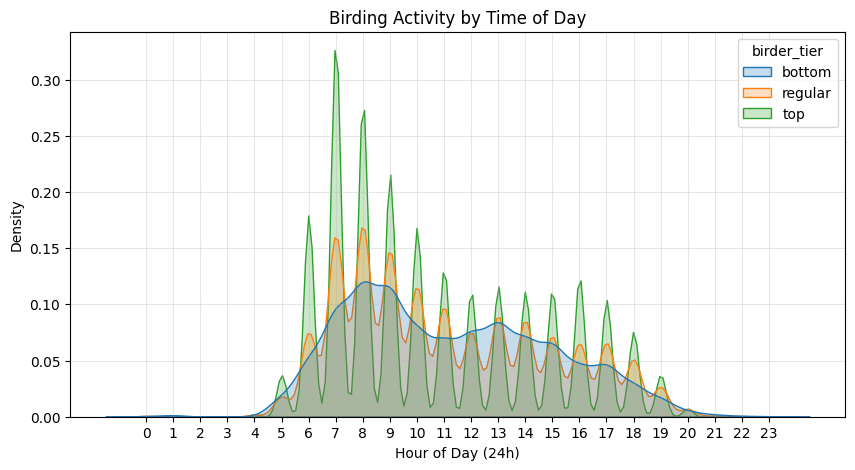

In [43]:
# Time of day comparison
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=ebird,
    x=pd.to_datetime(ebird['TIME OBSERVATIONS STARTED']).dt.hour,
    hue='birder_tier',
    common_norm=False,
    fill=True
)
plt.title('Birding Activity by Time of Day')
plt.xlabel('Hour of Day (24h)')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

## Summary

** Duplicated from insights generate abve after each block of analysis

**DATA SCOPE SUMMARY** 

Geographic: United States, Wisconsin, Dane

Time Period: 2015-01-01 to 2025-01-31 (3684 days with observations)

Total Checklists: 4,298,659  

Unique Species:   465

**What is the distribution of numerical feature values across the samples?**

Checklist Completeness Summary:
- 16.6% lack duration data
- 47.8% lack distance data
- 99.9% lack area data
- 13.2% of checklists have media

Birding Effort Summary with Available Data:
- Median outing duration: 37.0 minutes
- Long outings (top 5%): over 152.0 minutes
- Median distance covered: 1.6 km
- Extensive surveys (top 5%): beyond 5.3 km
- Due to high % of missing value in area data, analyzing it is not as meaningful
- 27.7% of checklists starts between 5:00 AM - 8:00 AM, when birds are most active.
- 95% of checklists have duration <= 3.2 hour and <= 6 km

**What is the distribution of categorical features?**

- 98% submitted category are species

- Top 3 most observed birds: Canada Goose, American Coot, Mallard

- Top 3 most diverse sites: Nine Springs Natural Area (318 species), UW Lakeshore Nature Preserve (general) (312 species), UW Madison Arboretum (general) (295 species). Combined they make up 80% of all 465 observed species.

- Top 3 birding hotspots (using unique count of submitted checklists): UW Madison Arboretum (general), Nine Springs Natural Area, Owen Conservation Park. These locations account for 7.4% of all 309857 checklists submitted.

- 51% of checklists are Traveling, 30% are Stationary

**Trend Analysis Summary**

- Number of active eBirders almost doubled starting from 2020, which is also when I(notebook auther) started birding, such a great activity to get out in the nature when you are stuck at home all day duing Covid~

- As expected, birding activity doubles on weekends, with 36.1% of checklists submitted on weekends. We observe a clear seasonal pattern in checklist submissions, with noticeable peaks during the spring and fall migration periods.

- Birding activity begins to increase in early March, reaches a sharp peak in early May, and then quickly declines before June. A smaller spike also appears in December, aligning with the annual Christmas Bird Count.

- In contrast to the intense activity during spring migration, the fall migration season is noticeably flatter and more subdued in terms of checklist volume. This could be due to lower species diversity in the fall, which peaks around 220 species, compared to the spring peak of approximately 290 species.

**Birder Engagement Summary**

If we categorize eBirders based on the number of checklists submitted into top 10%, regular, and bottom 10%, we can observe some distinct patterns in their birding behavior:
- Top 10% birders contributed 89.6% of all checklists.

- Given that top eBirders contribute nearly 90% of all checklists, their birding behavior is largely representative of overall trends observed in the data. This heavy contribution skews the aggregate patterns—such as peak birding times and trip characteristics—toward the habits of this highly active group.

- Top birders are more likely to start birding early in the morning: 38% of top birders begin before 9 AM, compared to only 29% of bottom birders.

- They also tend to have shorter trips—both in terms of duration and distance.

- Despite shorter trips, top birders observe significantly more species:
    - Top 10%: Average of 12.78 species per checklist
    - Regular: Average of 1.01 species
    - Bottom 10%: Only 0.07 species on average
    - This suggests that top birders are not only more experienced and efficient but also likely more deliberate in their birding efforts.